In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem: Assessing the state of global coffee production and consumption

## Find spearheading coffee producing nations: top 10 coffee producers by total production.

In [2]:
path = "./total-production.csv"

In [3]:
coffee_production = pd.read_csv(path, encoding="utf-8", sep=",")

In [4]:
coffee_production.head()

,total_production,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Angola,50.3450,79.3310,77.5200,32.6080,76.802,62.1090,70.925,64.330,85.3440,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
1,Bolivia (Plurinational State of),122.7770,103.5360,120.2350,50.8230,116.944,142.4850,124.579,140.719,137.9850,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687
2,Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,...,43976.8120,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836
3,Burundi,487.3930,667.1990,620.2380,393.3540,664.143,433.9800,400.969,249.785,491.9920,...,111.6130,352.9776,204.1328,405.9615,163.2177,247.5500,274.1017,248.7933,202.1079,178.4206
4,Ecuador,1503.8150,2123.8240,1185.4800,2069.0070,2375.766,1888.2330,1992.914,1190.663,1205.9680,...,813.2849,853.9798,825.4144,828.1024,665.5450,644.0112,644.4926,644.8845,623.5744,601.0001


In [5]:
coffee_production.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   total_production  56 non-null     str    
 1   1990              56 non-null     float64
 2   1991              56 non-null     float64
 3   1992              56 non-null     float64
 4   1993              56 non-null     float64
 5   1994              56 non-null     float64
 6   1995              56 non-null     float64
 7   1996              56 non-null     float64
 8   1997              56 non-null     float64
 9   1998              56 non-null     float64
 10  1999              56 non-null     float64
 11  2000              56 non-null     float64
 12  2001              56 non-null     float64
 13  2002              56 non-null     float64
 14  2003              56 non-null     float64
 15  2004              56 non-null     float64
 16  2005              56 non-null     float64
 17  2006      

In [6]:
coffee_production = (coffee_production
	.rename(columns={"total_production":"Country"})
	.set_index("Country")
	.assign(TotalProduction=lambda x: x.sum(axis=1))
	.sort_values(by="TotalProduction", ascending=False)
		   )

top10_producers = coffee_production[:10]
top10_producers

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,TotalProduction
Country,,,,,,,,,,,,,,,,,,,,,
Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,47577.8065,...,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836,1.190966e+06
Viet Nam,1310.2880,1437.8480,2340.4470,3020.2160,3631.609,3970.0860,5752.481,6978.942,7051.7220,11630.9138,...,19999.9999,26499.6111,23402.1057,27609.7814,26499.8404,28736.5941,25540.2932,27887.6555,31174.0742,4.395410e+05
Colombia,14396.0000,17980.3970,14946.8780,11422.4220,12964.000,12938.0180,10778.850,12122.496,10867.9620,9512.2459,...,8522.6594,7653.3336,9926.9445,12124.0702,13333.3435,14008.7814,14634.3893,13824.0725,13857.9620,3.458714e+05
Indonesia,7441.3830,8493.1960,5569.4780,6743.2880,5367.878,4573.4290,8220.584,7620.778,7295.9550,6557.0662,...,9128.5118,6888.9233,13070.0386,12900.9493,10946.2773,12585.4751,11541.0266,10852.3153,9417.5942,2.451168e+05
Ethiopia,2909.4510,2924.6640,1825.1710,2967.0040,2762.730,3165.3220,3407.442,3056.864,2927.7250,3784.0510,...,7500.3848,6798.4099,6233.0066,6427.4439,6575.2618,6713.9754,7296.9796,7453.7332,7776.2234,1.415429e+05
India,2828.6870,2999.7490,2823.4970,3533.1810,3001.564,4012.0260,3417.121,4108.756,4416.7680,4866.5892,...,5599.9734,5333.5414,5403.4408,5075.3312,5449.8670,5830.3381,6160.9436,5813.2238,5302.3920,1.320257e+05
Mexico,4674.2450,4727.2060,3400.8110,5023.4880,4158.777,5299.8880,5109.551,4801.561,4801.3480,6218.6765,...,4001.4319,4561.0578,4326.9422,3916.4766,3636.4007,2772.0393,3635.2949,4484.5814,4350.7012,1.269082e+05
Guatemala,3270.5290,3496.5310,4318.4830,3535.5010,3787.336,4001.6040,4524.556,4219.373,4892.9640,5120.1288,...,3949.9335,3850.3876,3762.9331,3189.3714,3310.0759,3409.7810,3684.2090,3733.7261,4006.7343,1.134011e+05
Honduras,1567.9580,2321.8080,1918.2090,1829.1790,2180.730,1909.2380,2004.388,2564.405,2195.1450,2985.0050,...,4330.6854,5882.1354,4685.9958,4583.0246,5268.2161,5785.7760,7456.8976,7559.7680,7327.8803,1.054566e+05


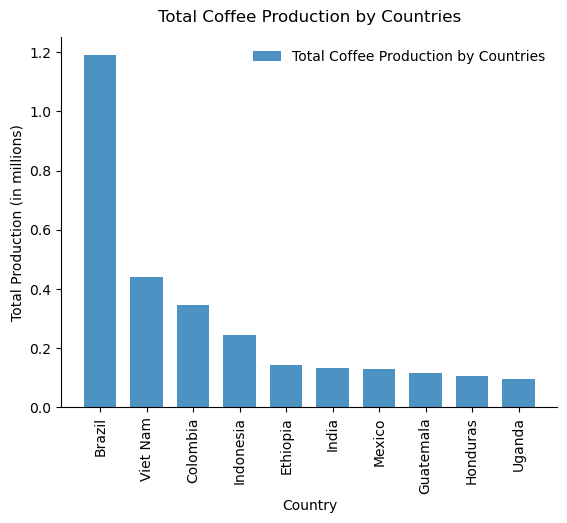

In [7]:
fig, ax1 = plt.subplots()

ax1.bar(
	x=top10_producers.index,
	height=top10_producers["TotalProduction"] / 1000000,
	width=0.7,
	align="center",

	linewidth=2,
	# hatch="+",

	label="Total Coffee Production by Countries",
	alpha=0.8
)

ax1.legend(frameon=False, fontsize=10)

ax1.set_title("Total Coffee Production by Countries", y=1.02)

ax1.set_xlabel(top10_producers.index.name)
ax1.set_ylabel("Total Production (in millions)")

plt.xticks(
	rotation=90
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False);

## Production trend of top 5 coffee producing nations through years

In [8]:
coffee_production_2 = (coffee_production
	.drop(columns="TotalProduction")
	.T
	.reset_index()
	.rename(columns=({"index":"Years"}))
	.astype({"Years":"datetime64[ns]"})
	.set_index("Years")
	   )

top5 = coffee_production_2.iloc[:,:5]
top5.head()

Country,Brazil,Viet Nam,Colombia,Indonesia,Ethiopia
Years,,,,,
1990-01-01,27285.6286,1310.288,14396.000,7441.383,2909.451
1991-01-01,27293.4934,1437.848,17980.397,8493.196,2924.664
1992-01-01,34603.3542,2340.447,14946.878,5569.478,1825.171
1993-01-01,28166.9786,3020.216,11422.422,6743.288,2967.004
1994-01-01,28192.0470,3631.609,12964.000,5367.878,2762.730


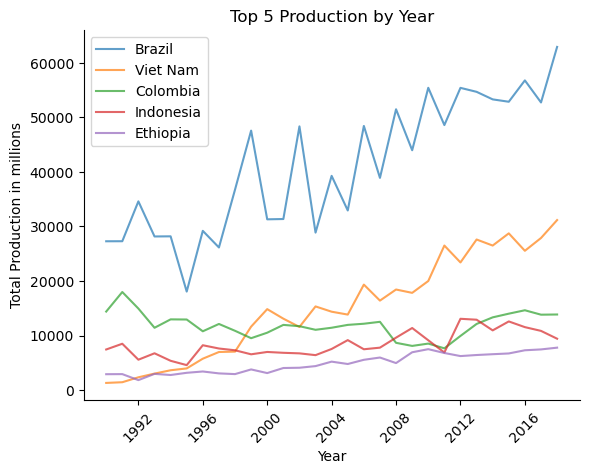

In [9]:
for column in top5:
	plt.plot(
		top5[column],
		label=column,
		alpha=0.7
	)
plt.legend(frameon=True, fontsize=10)

plt.title("Top 5 Production by Year")

plt.xlabel("Year")
plt.ylabel("Total Production in millions")

plt.xticks(rotation=45)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False);

## Comparison of coffee production of Brazil, number one, to that of the rest of the world through years.

In [10]:
brazil_vs_others = pd.concat([coffee_production_2.iloc[:, 0],
							pd.DataFrame(coffee_production_2.iloc[:,1:].sum(axis=1), columns=["OTH"])], axis=1
							)

brazil_vs_others.head()

,Brazil,OTH
Years,,
1990-01-01,27285.6286,65944.431
1991-01-01,27293.4934,73973.191
1992-01-01,34603.3542,63922.545
1993-01-01,28166.9786,63597.643
1994-01-01,28192.0470,65121.147


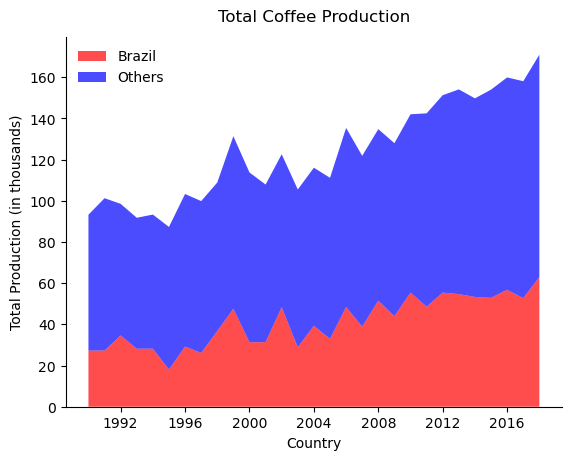

In [11]:
plt.stackplot(
	brazil_vs_others.index,
	brazil_vs_others["Brazil"] / 1000,
	brazil_vs_others["OTH"] / 1000,
	
	colors=("r", "b"),
	# edgecolor="0.0",
	# linewidth=1,

	# hatch="x",
	baseline="zero",
	zorder=3,

	alpha=0.7,
	labels=["Brazil", "Others"]
)

plt.legend(frameon=False, fontsize=10)

plt.title("Total Coffee Production", y=1.02)

plt.xlabel(top10_producers.index.name)
plt.ylabel("Total Production (in thousands)")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False);

## Comparison of coffee production of Brazil, number one, to that of Vietnam, number two, through years.

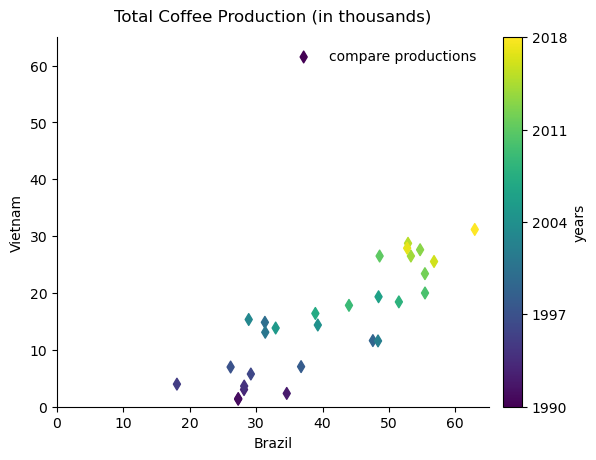

In [12]:
sc = plt.scatter(
	top5.loc[:,"Brazil"] / 1000, top5.loc[:,"Viet Nam"] / 1000,
	c=top5.index.year,
	marker="d",
	linewidth=1,

	cmap="viridis",
	
	label="compare productions"
)

plt.colorbar(
	mappable=sc,
	ax=None,
	orientation="vertical",
	fraction=0.1,
	ticks=[1990, 1997, 2004, 2011, 2018],
	pad=0.03,
	label="years")

plt.legend(frameon=False, fontsize=10)
plt.title("Total Coffee Production (in thousands)", y=1.02)

plt.xlabel("Brazil")
plt.ylabel("Vietnam")

plt.xlim(0, 65)
plt.ylim(0, 65)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False);

## COMPOSITION OF COFFEE PRODUCTION BY BRAZIL, 5 FOLLOWERS and the rest of the world.

In [13]:
coffee_production.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,TotalProduction
Country,,,,,,,,,,,,,,,,,,,,,
Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,47577.8065,...,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836,1.190966e+06
Viet Nam,1310.2880,1437.8480,2340.4470,3020.2160,3631.609,3970.0860,5752.481,6978.942,7051.7220,11630.9138,...,19999.9999,26499.6111,23402.1057,27609.7814,26499.8404,28736.5941,25540.2932,27887.6555,31174.0742,4.395410e+05
Colombia,14396.0000,17980.3970,14946.8780,11422.4220,12964.000,12938.0180,10778.850,12122.496,10867.9620,9512.2459,...,8522.6594,7653.3336,9926.9445,12124.0702,13333.3435,14008.7814,14634.3893,13824.0725,13857.9620,3.458714e+05
Indonesia,7441.3830,8493.1960,5569.4780,6743.2880,5367.878,4573.4290,8220.584,7620.778,7295.9550,6557.0662,...,9128.5118,6888.9233,13070.0386,12900.9493,10946.2773,12585.4751,11541.0266,10852.3153,9417.5942,2.451168e+05
Ethiopia,2909.4510,2924.6640,1825.1710,2967.0040,2762.730,3165.3220,3407.442,3056.864,2927.7250,3784.0510,...,7500.3848,6798.4099,6233.0066,6427.4439,6575.2618,6713.9754,7296.9796,7453.7332,7776.2234,1.415429e+05


In [14]:
coffee_production_top5_2018 = pd.concat(
	[
		coffee_production.iloc[:6, -1],
		pd.DataFrame(
			[coffee_production.iloc[6:,-1].sum(axis=0)],
			columns=["TotalProduction"],
			index=["OTH"]
		)
	]
	, axis=0)

coffee_production_top5_2018 

,TotalProduction
Brazil,1.190966e+06
Viet Nam,4.395410e+05
Colombia,3.458714e+05
Indonesia,2.451168e+05
Ethiopia,1.415429e+05
India,1.320257e+05
OTH,1.093366e+06


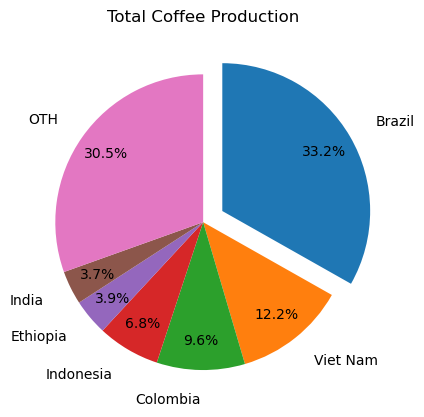

In [15]:
plt.pie(
	coffee_production_top5_2018.iloc[:,0],
	labels=coffee_production_top5_2018.index,
	labeldistance=1.2,
	autopct="%1.1f%%",
	pctdistance=0.8,
	textprops={"color":"black", "fontsize":"10"},

	explode=(0.15, 0, 0, 0, 0, 0, 0),
	# wedgeprops={"width":0.35},

	startangle=90,
	counterclock=False

)

plt.title("Total Coffee Production", y=1.02);

## Brazil's share of global production in 1990, and in 2018.

In [16]:
brazil_vs_others.head()

,Brazil,OTH
Years,,
1990-01-01,27285.6286,65944.431
1991-01-01,27293.4934,73973.191
1992-01-01,34603.3542,63922.545
1993-01-01,28166.9786,63597.643
1994-01-01,28192.0470,65121.147


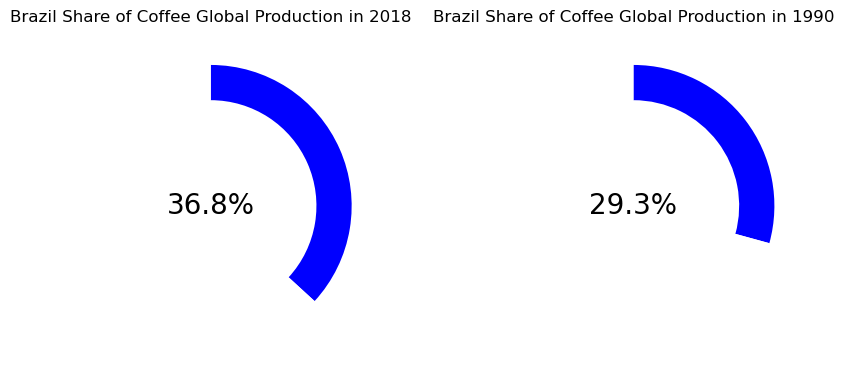

In [17]:
fig, ax= plt.subplots(figsize=(10, 6), ncols=2, nrows=1)

for i in range(1, -1, -1):
	wedges, texts, autotexts = ax[i].pie(
		brazil_vs_others.iloc[i-1],
		labels=["Brazil", "OTH"],
		labeldistance=1.2,
		autopct="%1.1f%%",
		pctdistance=0,
		textprops={"color":"black", "fontsize":"20"},
	
		colors=("b", "white"),
		wedgeprops={"width":0.25},
	
		startangle=90,
		counterclock=False
	)
	
	ax[i].set_title(f"Brazil Share of Coffee Global Production in {brazil_vs_others.index[i-1].year}")
	
	for i, item in enumerate(autotexts):
	    if i != 0: 
	        item.set_text("")
	for i, item in enumerate(texts):
	    item.set_text("") 

## Coffee Consumption Vs. Prices among countries

In [18]:
consumption = pd.read_csv("./imports.csv")
consumption.head()

,imports,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Austria,1880.0,2058.0,2206.0,1836.0,1417.0,1231.0,1210.0,1294.0,1293.0,...,1309.0,1369.0,1452.0,1559.0,1555.0,NaN,NaN,NaN,NaN,NaN
1,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5916.0,5924.0,5828.0,5668.0,5502.0,NaN,NaN,NaN,NaN,NaN
2,Belgium/Luxembourg,2015.0,1746.0,1828.0,2063.0,2262.0,2401.0,2526.0,2544.0,3580.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bulgaria,268.0,200.0,182.0,397.0,463.0,515.0,272.0,294.0,342.0,...,523.0,528.0,482.0,560.0,609.0,NaN,NaN,NaN,NaN,NaN
4,Croatia,NaN,NaN,168.0,163.0,193.0,320.0,322.0,385.0,339.0,...,394.0,394.0,391.0,384.0,413.0,NaN,NaN,NaN,NaN,NaN


In [19]:
consumption = (consumption
	.rename(columns={"imports":"countries"})
	.set_index("countries")
	.assign(AvgConsumption=lambda x: x.mean(numeric_only=True, axis=1))
	[["AvgConsumption"]]
			  )

consumption.head()

,AvgConsumption
countries,
Austria,1551.083333
Belgium,4639.533333
Belgium/Luxembourg,2329.444444
Bulgaria,397.250000
Croatia,349.136364


In [20]:
prices = pd.read_csv("./retail-prices.csv")
prices.tail()

,retail_prices,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
9,Spain,7.991170,7.726269,7.726269,6.158940,6.092715,9.823400,9.227373,7.880795,7.991170,...,9.183223,8.653422,9.757174,9.867550,10.000000,9.801325,8.432671,8.233996,8.476821,9.050773
10,Sweden,7.571744,7.262693,6.865342,5.849890,8.366446,10.706402,8.741722,9.602649,9.735099,...,7.836645,8.807947,12.317881,11.479029,9.580574,9.072848,8.432671,7.682119,7.880795,7.152318
11,United Kingdom,23.289183,22.980132,22.273731,18.631347,25.077263,30.441501,29.470199,32.891832,34.039735,...,35.298013,34.657837,41.986755,42.384106,41.766004,45.386313,41.743929,35.960265,37.549669,40.618102
12,Japan,22.649007,26.225166,27.858720,32.163355,32.428256,39.116998,33.642384,31.390728,29.845475,...,13.399558,14.105960,16.225166,16.710817,13.355408,12.538631,12.362031,13.708609,13.134658,12.803532
13,Norway,7.306843,6.975717,6.887417,5.430464,7.262693,10.022075,8.609272,9.072848,8.609272,...,8.874172,9.889625,12.759382,12.097130,11.147903,16.556291,12.825607,12.273731,12.428256,12.693157


In [21]:
prices = (prices
	.rename(columns={"retail_prices":"countries"})
	.set_index("countries")
	.assign(AvgPrice=lambda x: x.mean(numeric_only=True, axis=1))
	[["AvgPrice"]]
		 )

prices.tail()

,AvgPrice
countries,
Spain,8.029992
Sweden,8.054350
United Kingdom,32.939027
Japan,21.472939
Norway,9.409302


In [22]:
price_cons = (pd.merge(consumption, prices, left_index=True, right_index=True, how="inner")
	.sort_values(by="AvgConsumption", ascending=False))

price_cons.head()

,AvgConsumption,AvgPrice
countries,,
Germany,16357.666667,9.515110
Japan,6862.275235,21.472939
Italy,6696.958333,14.199589
France,6512.458333,6.850879
Spain,4046.291667,8.029992


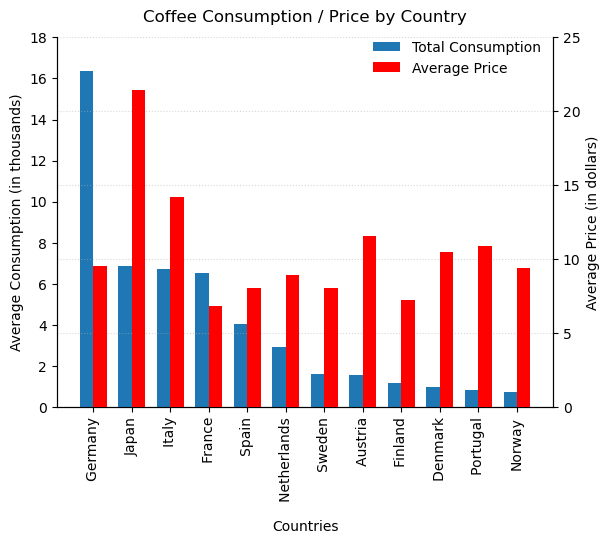

In [23]:
fig = plt.figure()
ax = fig.add_subplot()

tick_counts = np.arange(price_cons.shape[0]-1)
width=0.35

ax.bar(
	x=tick_counts + width,
	height=price_cons.iloc[:-1, 0] / 1000,
	width=width,
	align="center",
	zorder=3,
	bottom=0,

	lw=2,

	alpha=1,
	label="Total Consumption"
)

ax2 = ax.twinx()

ax2.bar(
	x=tick_counts + width * 2,
	height=price_cons.iloc[:-1, 1],
	width=width,
	align="center",
	zorder=3,
	bottom=0,

	lw=2,
	color="r",

	alpha=1,
	label="Average Price"
)

ax.set_title("Coffee Consumption / Price by Country", y=1.02)

ax.set_xlabel("Countries")
ax.set_ylabel("Average Consumption (in thousands)")
ax2.set_ylabel("Average Price (in dollars)")

ax.set_ylim(0, 18)
ax2.set_ylim(0, 25)

plt.xticks(
	ticks=tick_counts + width * 1.5)
ax.set_xticklabels(labels=price_cons.index[:-1], rotation=90)

ax2.grid(which="major", axis="y", linestyle=":", alpha=0.5)

fig.legend(frameon=False, fontsize=10, bbox_to_anchor=(0.9, 0.9))

ax.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False);